# 🔬 Notebook 05 - SINDy Discovery (STLSQ)
**SINDy with Environmental Covariates on DengAI Data**

---
### Objectives
1. Set up train/test splits (San Juan: 1990-2005 train, 2006-2008 test).
2. Use Sequential Thresholded Least Squares (STLSQ) on the custom library to discover the governing equation for $d(i_h)/dt$.
3. Perform a threshold sweep (0.001 to 0.1) to find the optimal balance between sparsity and accuracy.
4. Select the best model and interpret the discovered functional form of $\beta(t)$.
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.append(r'c:\users\mayank gupta\appdata\roaming\python\python312\site-packages')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pysindy.optimizers import STLSQ
from sklearn.metrics import mean_squared_error

from src.plot_utils import set_project_style, PALETTE, city_label, city_color, save_fig

set_project_style()
print('All imports ready')

All imports ready


## 1 . Load Library and Dynamics Data

In [2]:
df_sj = pd.read_csv('../data_processed/sj_dynamics.csv', parse_dates=['week_start_date'])
Theta_sj = pd.read_csv('../data_processed/library_sj_norm.csv')
targets_sj = pd.read_csv('../data_processed/targets_sj.csv')

# Target is d(i_h)/dt
y_sj = targets_sj['di_h_dt'].values

print(f'San Juan library shape: {Theta_sj.shape}')
print(f'Target vector shape: {y_sj.shape}')

San Juan library shape: (933, 63)
Target vector shape: (933,)


## 2 . Train/Test Split
Blueprint specifies: Train on San Juan 1990–2005, Test on 2006–2008.

In [3]:
train_mask = df_sj['year'] <= 2005
test_mask = df_sj['year'] >= 2006

Theta_train = Theta_sj[train_mask].values
y_train = y_sj[train_mask]

Theta_test = Theta_sj[test_mask].values
y_test = y_sj[test_mask]

print(f'Train size: {Theta_train.shape[0]} weeks')
print(f'Test size : {Theta_test.shape[0]} weeks')

Train size: 812 weeks
Test size : 121 weeks


## 3 . STLSQ Threshold Sweep
We sweep the threshold $\lambda$ from 0.001 to 0.1 to identify the Pareto front of model complexity vs. error.

In [4]:
thresholds = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
results = []

feature_names = Theta_sj.columns.tolist()

for th in thresholds:
    # alpha is the ridge penalty in STLSQ
    optimizer = STLSQ(threshold=th, alpha=1e-3, max_iter=100)
    optimizer.fit(Theta_train, y_train)
    
    coefs = optimizer.coef_[0]
    active_terms = np.sum(coefs != 0)
    
    # Predict
    y_train_pred = optimizer.predict(Theta_train)
    y_test_pred = optimizer.predict(Theta_test)
    
    # Calculate NRMSE (Normalised RMSE)
    # Normalised by standard deviation of the true target
    train_nrmse = np.sqrt(mean_squared_error(y_train, y_train_pred)) / np.std(y_train)
    test_nrmse = np.sqrt(mean_squared_error(y_test, y_test_pred)) / np.std(y_test)
    
    # Extract active features
    eq_terms = [f"{coefs[i]:.4e} * {feature_names[i]}" for i in range(len(coefs)) if coefs[i] != 0]
    
    results.append({
        'threshold': th,
        'active_terms': active_terms,
        'train_nrmse': train_nrmse,
        'test_nrmse': test_nrmse,
        'equation': ' + '.join(eq_terms) if active_terms > 0 else '0'
    })

df_results = pd.DataFrame(results)
display(df_results[['threshold', 'active_terms', 'train_nrmse', 'test_nrmse']])

c:\users\mayank gupta\appdata\roaming\python\python312\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.001) and eliminated all coefficients
  warnings.warn(
c:\users\mayank gupta\appdata\roaming\python\python312\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.005) and eliminated all coefficients
  warnings.warn(
c:\users\mayank gupta\appdata\roaming\python\python312\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
c:\users\mayank gupta\appdata\roaming\python\python312\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.02) and eliminated all coefficients
  warnings.warn(
c:\users\mayank gupta\appdata\roaming\python\python312\site-packages\pysindy\optimizers\stlsq.py:224: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings

,threshold,active_terms,train_nrmse,test_nrmse
0,0.0001,16,0.810750,0.961997
1,0.0005,3,0.946916,0.956626
2,0.0010,0,1.000001,1.000068
3,0.0050,0,1.000001,1.000068
4,0.0100,0,1.000001,1.000068
5,0.0200,0,1.000001,1.000068
6,0.0500,0,1.000001,1.000068
7,0.1000,0,1.000001,1.000068


  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\05_pareto_front.png


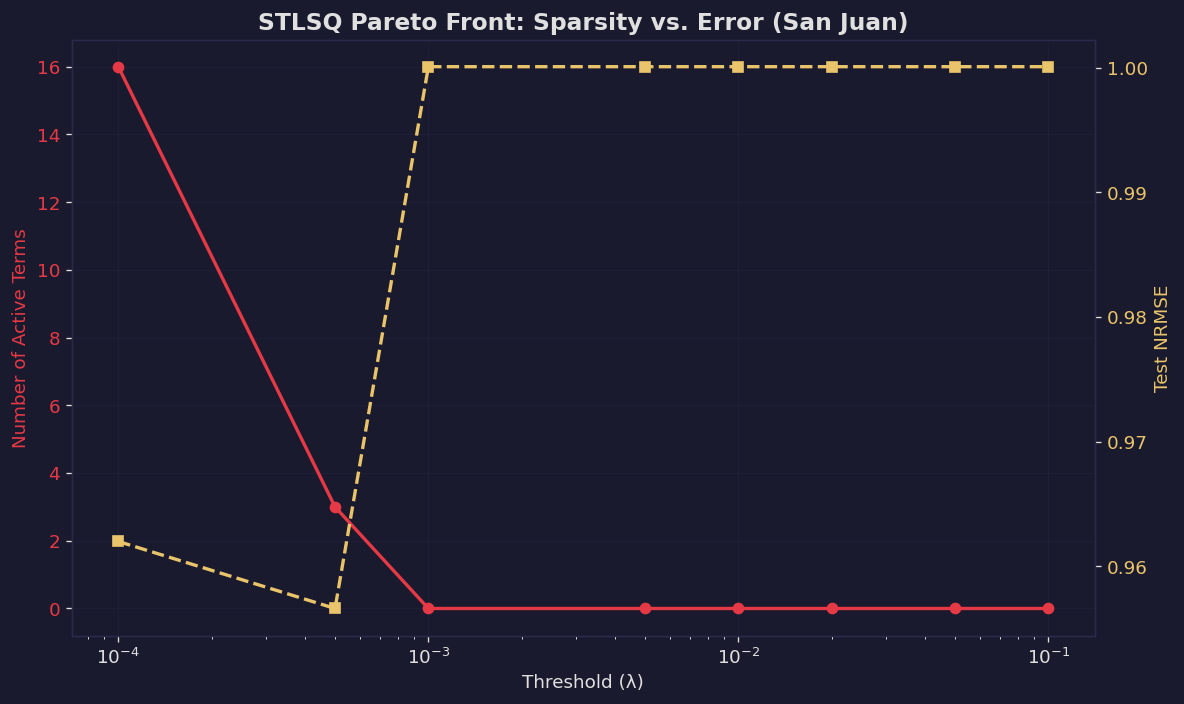

In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = PALETTE['sj']
ax1.set_xlabel('Threshold (λ)')
ax1.set_ylabel('Number of Active Terms', color=color1)
ax1.plot(df_results['threshold'], df_results['active_terms'], marker='o', color=color1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color2 = '#E9C46A'
ax2.set_ylabel('Test NRMSE', color=color2)
ax2.plot(df_results['threshold'], df_results['test_nrmse'], marker='s', color=color2, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('STLSQ Pareto Front: Sparsity vs. Error (San Juan)', fontsize=14)
fig.tight_layout()
ax1.grid(True, alpha=0.3)
save_fig(fig, '05_pareto_front')
plt.show()

## 4 . Select Best Model
We want a model that is sparse (interpretable, < 15 terms) but still accurately captures the dynamics (low NRMSE).

In [6]:
# Let's pick a threshold that gives a reasonable number of terms (e.g., > 0 and <= 20)
valid_models = df_results[(df_results['active_terms'] > 0) & (df_results['active_terms'] <= 20)]
if not valid_models.empty:
    best_idx = valid_models['test_nrmse'].idxmin()
else:
    best_idx = df_results[df_results['active_terms'] > 0]['test_nrmse'].idxmin()
best_model = df_results.loc[best_idx]

print('=== BEST MODEL DISCOVERED ===')
print(f"Threshold    : {best_model['threshold']}")
print(f"Active Terms : {best_model['active_terms']}")
print(f"Train NRMSE  : {best_model['train_nrmse']:.4f}")
print(f"Test NRMSE   : {best_model['test_nrmse']:.4f}")
print('\nDiscovered Equation for d(i_h)/dt:')
eq = best_model['equation'].replace(' + -', ' - ')
for term in eq.split(' + '):
    print(f'  + {term}')

=== BEST MODEL DISCOVERED ===
Threshold    : 0.0005
Active Terms : 3
Train NRMSE  : 0.9469
Test NRMSE   : 0.9566

Discovered Equation for d(i_h)/dt:
  + -2.2033e-03 * i_h
  + 4.4710e-03 * si*H - 2.2730e-03 * si*H^2


## 5 . Visualise Best Model Predictions on Test Set

  ✅ Saved → D:\Mayank\dengue-sindy-env-dynamics\figures\05_test_predictions.png


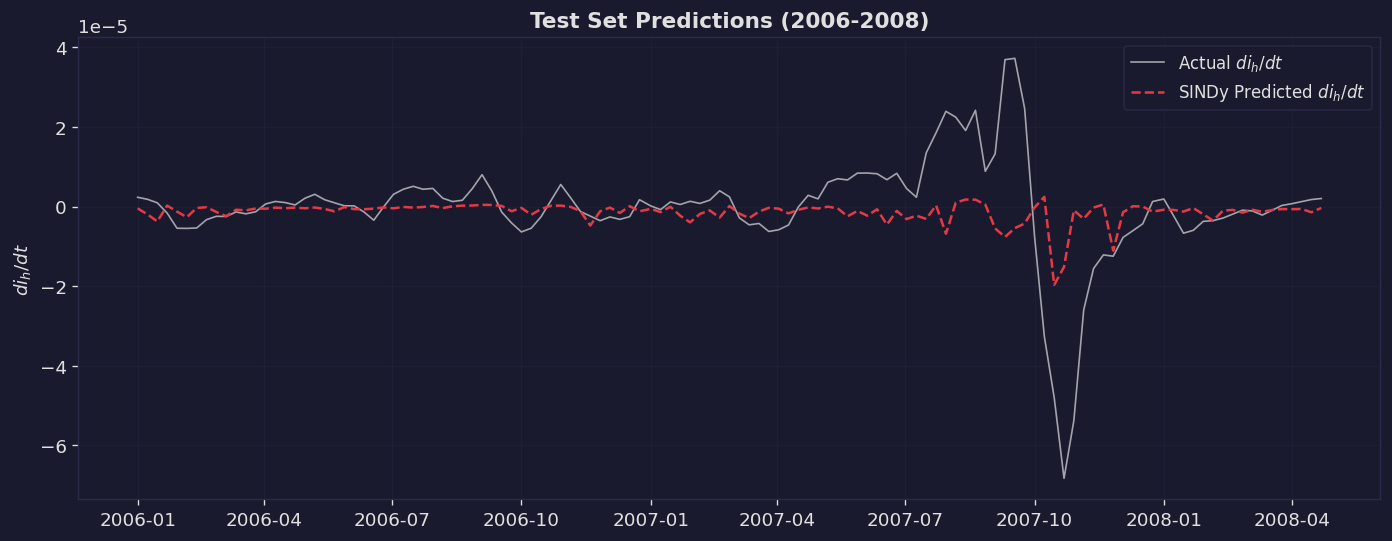

In [7]:
# Re-fit the best model to get actual predictions
best_opt = STLSQ(threshold=best_model['threshold'], alpha=1e-3, max_iter=100)
best_opt.fit(Theta_train, y_train)

y_test_pred = best_opt.predict(Theta_test)

fig, ax = plt.subplots(figsize=(14, 5))
test_dates = df_sj[test_mask]['week_start_date']

ax.plot(test_dates, y_test, label='Actual $di_h/dt$', color='white', alpha=0.6, linewidth=1)
ax.plot(test_dates, y_test_pred, label='SINDy Predicted $di_h/dt$', color=PALETTE['sj'], linewidth=1.5, linestyle='--')

ax.set_title('Test Set Predictions (2006-2008)', fontsize=13)
ax.set_ylabel('$di_h/dt$')
ax.legend()
ax.grid(True, alpha=0.3)
save_fig(fig, '05_test_predictions')
plt.show()

## 6 . Preparation for Baseline Comparison (Notebook 06)
Save the discovered best threshold so it can be applied to Iquitos.

In [8]:
import json
config = {
    'best_threshold': float(best_model['threshold']),
    'test_nrmse': float(best_model['test_nrmse'])
}
with open('../data_processed/sindy_config.json', 'w') as f:
    json.dump(config, f)
print('Saved SINDy configuration.')

Saved SINDy configuration.
